# Comprehensive fibril model parameter sweeps

## Notebook setup

### Imports

In [1]:
# Imports
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
from scipy.spatial.transform import Rotation as R
from tqdm.auto import tqdm
import sys
import json
from itertools import product
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from collections import defaultdict
import gc
from scipy.stats import skewnorm, norm, vonmises


from custom_fibril_gen_v2 import *
from nrss_fibril_functions_v2 import *

### Define Paths

In [2]:
notebookPath = pathlib.Path.cwd()
# savePath = notebookPath.joinpath('simple_fibril_sweeps_outputs')
savePath = notebookPath.joinpath('multiple_fibril_sweeps_outputs')
# fibrilsPath = basePath.joinpath('custom_fibril_gen', f'fixed_fibrils')

In [3]:
savePath.exists()

True

## Functions

In [4]:
# # Define functions
# def orientation(scenario, rotated_bb_coords, rotated_bb_axs, rotated_bb_css, rotated_fibril, set_theta):
#     """
#     Assigns ZY Euler orientation angles (psi, theta) for molecular extraordinary axes
#     in different alignment scenarios relative to the local fibril axis.

#     Parameters:
#     - scenario: str
#         Molecular extraordinary axis orientation scenario identifier:
#           A = Type II (para. to long axis): theta=long_axis_theta, psi=long_axis_psi
#           B = Custom  (indp. to long axis): Set declination; theta=set_theta,  psi=long_axis_psi+90°
#           C = Type I  (perp. to long axis): Radial; always point away from center of fibril cross sections         
#           D = Type I  (perp. to long axis): Random; always point in the plane of the fibril cross sections
#     - rotated_bb_coords: (N, 3) np.ndarray
#         Backbone centerline positions along fibril long axis after rotation
#     - rotated_bb_axs: (N, 3) np.ndarray
#         Backbone axial unit vectors (long axis) after rotation
#     - rotated_bb_css: (N, 2, 3) np.ndarray
#         Backbone short-axis vectors (cross-sectional frame, 2 vectors per backbone point)
#     - rotated_fibril: (M, 3) np.ndarray
#         3D fibril coordinate positions (Å)
#     - set_theta: int or float
#         Used in Scenario B to specify declination angle

#     Returns:
#     - fibril_ZYrots: (M, 2) np.ndarray
#         Euler ZY rotation angles in degrees (psi ∈ [0,360), theta ∈ [0,180]) per fibril point in degrees
#     """
#     M = rotated_fibril.shape[0]
#     fibril_ZYrots = np.zeros((M, 2))
#     rng = np.random.default_rng()

#     if scenario == 'A':
#         psi = np.rad2deg(np.arctan2(rotated_bb_axs[:, 1], rotated_bb_axs[:, 0])) % 360
#         theta = np.rad2deg(np.arccos(rotated_bb_axs[:, 2])) % 180
#         euler_ZY_rot = np.vstack((psi, theta)).T
#         for i, fibril_point in enumerate(rotated_fibril):
#             d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
#             idx = np.argmin(d)
#             fibril_ZYrots[i] = euler_ZY_rot[idx]
            
#     elif scenario == 'B':
#         for i, fibril_point in enumerate(rotated_fibril):
#             d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
#             idx = np.argmin(d)
#             axis_vec = rotated_bb_axs[idx]
#             psi = (np.rad2deg(np.arctan2(axis_vec[1], axis_vec[0])) + 90) % 360
#             fibril_ZYrots[i] = [psi, set_theta]
    
#     elif scenario == 'C': 
#         for i, fibril_point in enumerate(rotated_fibril):
#             bb_displacements = rotated_bb_coords - fibril_point
#             bb_distances = np.linalg.norm(bb_displacements, axis=1)
#             bb_min_idx = np.argmin(bb_distances)

#             min_displacement = bb_displacements[bb_min_idx]
#             orient_vec = -min_displacement / np.linalg.norm(min_displacement)

#             theta = np.rad2deg(np.arccos(orient_vec[2])) % 180
#             psi = np.rad2deg(np.arctan2(orient_vec[1], orient_vec[0])) % 360
#             fibril_ZYrots[i] = [psi, theta]

#     elif scenario == 'D': 
#         for i, fibril_point in enumerate(rotated_fibril):
#             dists = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
#             idx = np.argmin(dists)

#             css1 = rotated_bb_css[0, idx]
#             css2 = rotated_bb_css[1, idx]

#             alpha = rng.uniform(0, 2 * np.pi)
#             orient_vec = np.cos(alpha) * css1 + np.sin(alpha) * css2
#             orient_vec = orient_vec / np.linalg.norm(orient_vec)

#             theta = np.rad2deg(np.arccos(orient_vec[2])) % 180
#             psi = np.rad2deg(np.arctan2(orient_vec[1], orient_vec[0])) % 360
#             fibril_ZYrots[i] = [psi, theta]
    
#     else:
#         raise ValueError(f"Unknown scenario '{scenario}'")

#     return fibril_ZYrots


In [5]:
# def orientation_vectors(scenario, rotated_bb_coords, rotated_bb_axs, rotated_bb_css, rotated_fibril, set_theta):
#     """
#     Assigns molecular extraordinary axis vectors (unit vectors) for each fibril point based on orientation scenario.

#     Orientation Scenarios:
#     - A: Type II: Aligns orientation vector parallel to the fibril long axis.
#     - B: Rotates from the local backbone axis by a fixed angle (set_theta).
#     - C: Type I: Points radially outward from the closest backbone centerline coordinate.
#     - D: Type I: Selects a random direction within the cross-sectional plane.
#     - E: Type I: Psi parallel to fibril long axis psi; Theta perpendicular

#     Parameters:
#     - scenario: str
#         Orientation scenario identifier (A, B, C, or D).
#     - rotated_bb_coords: (N, 3) np.ndarray
#         Backbone centerline coordinates after global rotation.
#     - rotated_bb_axs: (N, 3) np.ndarray
#         Local backbone long-axis unit vectors.
#     - rotated_bb_css: (N, 2, 3) np.ndarray
#         Short-axis cross-sectional unit vectors for each backbone point (2 per point).
#     - rotated_fibril: (M, 3) np.ndarray
#         Coordinates of points along the fibril for which orientations are needed.
#     - set_theta: float
#         Declination angle in degrees for scenario B.

#     Returns:
#     - fibril_vectors: (M, 3) np.ndarray
#         Molecular orientation unit vectors (x, y, z) for each fibril point.
#     """
#     M = rotated_fibril.shape[0]  # number of fibril points
#     fibril_vectors = np.zeros((M, 3))  # initialize output array
#     rng = np.random.default_rng()  # random number generator for scenario D

#     if scenario == 'A':
#         # Orientation is aligned with local backbone long axis
#         for i, fibril_point in enumerate(rotated_fibril):
#             # Find nearest backbone point to fibril point
#             d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
#             idx = np.argmin(d)
#             # Use its long-axis vector as orientation
#             fibril_vectors[i] = rotated_bb_axs[idx]

#     elif scenario == 'B':
#         # Orientation is rotated from the backbone long axis by set_theta degrees
#         theta_rad = np.deg2rad(set_theta)
#         for i, fibril_point in enumerate(rotated_fibril):
#             # Find nearest backbone point
#             d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
#             idx = np.argmin(d)
#             long_axis_vec = rotated_bb_axs[idx]  # local backbone axis vector
#             # Construct orthogonal vector to long_axis_vec
#             ortho_vec = np.cross(long_axis_vec, [0, 0, 1])  # try using z-axis
#             if np.linalg.norm(ortho_vec) < 1e-6:
#                 ortho_vec = np.cross(long_axis_vec, [0, 1, 0])  # fallback if nearly parallel
#             ortho_vec /= np.linalg.norm(ortho_vec)
#             # Combine axis and orthogonal vector using the declination angle
#             orient_vec = np.cos(theta_rad) * long_axis_vec + np.sin(theta_rad) * ortho_vec
#             fibril_vectors[i] = orient_vec / np.linalg.norm(orient_vec)

#     elif scenario == 'C':
#         # Orientation points outward from fibril toward closest backbone point
#         for i, fibril_point in enumerate(rotated_fibril):
#             # Compute displacements from all backbone points
#             bb_displacements = rotated_bb_coords - fibril_point
#             bb_distances = np.linalg.norm(bb_displacements, axis=1)
#             idx = np.argmin(bb_distances)
#             # Vector pointing from fibril point to backbone (reversed)
#             displacement = bb_displacements[idx]
#             fibril_vectors[i] = -displacement / np.linalg.norm(displacement)

#     elif scenario == 'D':
#         # Orientation is random within the cross-sectional plane
#         for i, fibril_point in enumerate(rotated_fibril):
#             # Find nearest backbone point
#             dists = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
#             idx = np.argmin(dists)
#             # Get two orthogonal cross-sectional directions at that point
#             css1 = rotated_bb_css[0, idx]  # short-axis vector 1
#             css2 = rotated_bb_css[1, idx]  # short-axis vector 2
#             # Choose a random linear combination of the two (unit circle)
#             alpha = rng.uniform(0, 2 * np.pi)
#             orient_vec = np.cos(alpha) * css1 + np.sin(alpha) * css2
#             fibril_vectors[i] = orient_vec / np.linalg.norm(orient_vec)
            
#     if scenario == 'E':
#         # Psi is aligned with fibril long axis psi: theta perpendicular
#         for i, fibril_point in enumerate(rotated_fibril):
#             # Find nearest backbone point to fibril point
#             d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
#             idx = np.argmin(d)
#             # Use its cross product with one of its two in-plane perpendicular vectors 

#             # For now just chose y-axis... only will work for specific long axis orientation
#             fibril_vectors[i] = np.cross(rotated_bb_axs[idx], [0,1,0])  
            
#     else:
#         raise ValueError(f"Unknown scenario '{scenario}'")

#     return fibril_vectors


# def style_axes(ax, background, hide_all=True):
#     if hide_all:
#         ax.set_axis_off()
#     else:
#         ax.set_xlabel("X")
#         ax.set_ylabel("Y")
#         ax.set_zlabel("Z")
#         ax.grid(False)
#         ax.xaxis.pane.set_visible(False)
#         ax.yaxis.pane.set_visible(False)
#         ax.zaxis.pane.set_visible(False)


# def set_equal_aspect_3d(ax, X, Y, Z, zoom=1.0):
#     max_range = np.array([X.max() - X.min(), Y.max() - Y.min(), Z.max() - Z.min()]).max() / 2.0
#     max_range *= zoom
#     mid_x = (X.max() + X.min()) * 0.5
#     mid_y = (Y.max() + Y.min()) * 0.5
#     mid_z = (Z.max() + Z.min()) * 0.5
#     ax.set_xlim(mid_x - max_range, mid_x + max_range)
#     ax.set_ylim(mid_y - max_range, mid_y + max_range)
#     ax.set_zlim(mid_z - max_range, mid_z + max_range)
#     ax.set_box_aspect([1, 1, 1])


# def orientation_sphere_legend(ax, radius=1.0, detail=60, offset=(0, 0, 0), length=100, scale=1, alpha=1.0):
#     """
#     Adds a colored orientation sphere to the current 3D plot.
#     RGB mapping:
#       - R = (x + 1) / 2
#       - G = (y + 1) / 2
#       - B = (z + 1) / 2
#     where (x, y, z) are unit vector components on the sphere.
#     """
#     u = np.linspace(0, 2 * np.pi, detail)
#     v = np.linspace(0, np.pi, detail)
#     u, v = np.meshgrid(u, v)

#     x = radius * np.cos(u) * np.sin(v)
#     y = radius * np.sin(u) * np.sin(v)
#     z = radius * np.cos(v)

#     # Normalize and map to RGB
#     R = (x / radius + 1) / 2
#     G = (y / radius + 1) / 2
#     B = (z / radius + 1) / 2
#     colors = np.stack([R, G, B], axis=-1)

#     # Plot surface with RGB mapping
#     ax.plot_surface(x * scale + offset[0],
#                     y * scale + offset[1],
#                     z * scale + offset[2] + length * 2,
#                     rstride=1, cstride=1, facecolors=colors,
#                     linewidth=0.1, antialiased=False, shade=False, alpha=alpha)
#     return ax


# def draw_quiver_axes(ax, origin=(0, 0, 0), length=0.1):
#     """
#     Draws RGB-colored quiver axes based on unit vector direction.
#     RGB mapping:
#       - X axis = red
#       - Y axis = green
#       - Z axis = blue
#     """
#     origin = np.atleast_2d(origin)
#     U = np.array([[length, 0, 0], [0, length, 0], [0, 0, length]])
#     X = np.repeat(origin, 3, axis=0)

#     colors = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]  # RGB for x, y, z

#     for i in range(3):
#         # ax.quiver(X[i, 0], X[i, 1], X[i, 2],
#         #           U[i, 0], U[i, 1], U[i, 2],
#         #           color='grey', linewidth=3, arrow_length_ratio=0.2)
#         ax.quiver(X[i, 0], X[i, 1], X[i, 2],
#                   U[i, 0], U[i, 1], U[i, 2],
#                   color=colors[i], linewidth=1, arrow_length_ratio=0.2)

#     ax.text(origin[0, 0] + length * 1.3, origin[0, 1], origin[0, 2], 'X', color='black')
#     ax.text(origin[0, 0], origin[0, 1] + length * 1.1, origin[0, 2], 'Y', color='black')
#     ax.text(origin[0, 0], origin[0, 1], origin[0, 2] + length * 1.1, 'Z', color='black')


# def plot_pointcloud(pcd, background="white", elev=45, azim=315, show=True, savePath=None,
#                     zoom=1.0, axes_origin=(0, 0, 0), sphere_origin=(0,0,100), axes_length=1, hide_axes=True):
#     points = np.asarray(pcd.points)
#     colors = np.asarray(pcd.colors) if pcd.has_colors() else "k"

#     fig = plt.figure(figsize=(8, 8))
#     fig.set(tight_layout=True)
#     ax = fig.add_subplot(111, projection='3d')
#     ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=2, c=colors)
    
#     # Equal aspect and axis arrows
#     set_equal_aspect_3d(ax, points[:, 0], points[:, 1], points[:, 2], zoom)
#     draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

#     # Styling
#     ax.set_facecolor(background)
#     fig.patch.set_facecolor(background)
#     ax.view_init(elev=elev, azim=azim)
#     style_axes(ax, background, hide_all=hide_axes)

#     if show:
#         plt.show()
#     if savePath:
#         fig.savefig(savePath, dpi=300)


# def plot_voxelgrid(voxel_grid, background="white", elev=45, azim=315, show=True, savePath=None,
#                    zoom=1.0, axes_origin=(0, 0, 0), axes_length=1, hide_axes=True):
#     voxel_size = voxel_grid.voxel_size
#     origin = voxel_grid.origin
#     voxels = voxel_grid.get_voxels()

#     indices = np.stack([v.grid_index for v in voxels])
#     colors = np.stack([v.color for v in voxels])
#     centers = indices * voxel_size + origin

#     r = voxel_size / 2
#     cube = np.array([[-r, -r, -r], [+r, -r, -r], [+r, +r, -r], [-r, +r, -r],
#                      [-r, -r, +r], [+r, -r, +r], [+r, +r, +r], [-r, +r, +r]])
#     faces = [[0,1,2,3], [4,5,6,7], [0,1,5,4],
#              [2,3,7,6], [1,2,6,5], [4,7,3,0]]

#     all_verts = []
#     face_colors = []

#     for center, color in zip(centers, colors):
#         verts = cube + center
#         all_verts.extend([verts[face] for face in faces])
#         face_colors.extend([color]*6)

#     fig = plt.figure(figsize=(8, 8))
#     fig.set(tight_layout=True)
#     ax = fig.add_subplot(111, projection='3d')
#     mesh = Poly3DCollection(all_verts, facecolors=face_colors, edgecolors='k', linewidths=0.05, alpha=0.95)
#     ax.add_collection3d(mesh)
    
#     # Equal aspect and axis arrows
#     set_equal_aspect_3d(ax, centers[:, 0], centers[:, 1], centers[:, 2], zoom)
#     draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

#     ax.set_facecolor(background)
#     fig.patch.set_facecolor(background)
#     ax.view_init(elev=elev, azim=azim)
#     style_axes(ax, background, hide_all=hide_axes)
    
#     if show:
#         plt.show()
#     if savePath:
#         fig.savefig(savePath, dpi=300)

        
# def plot_pointcloud_with_legend(pcd, background="white", elev=45, azim=315, show=True, savePath=None,
#                                 zoom=1.0, axes_origin=(0, 0, 0), sphere_origin=(0,0,100), axes_length=1, hide_axes=True):
#     points = np.asarray(pcd.points)
#     colors = np.asarray(pcd.colors) if pcd.has_colors() else "k"

#     fig = plt.figure(figsize=(8, 8))
#     fig.set(tight_layout=True)
#     ax = fig.add_subplot(111, projection='3d')
#     ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=2, c=colors)

#     # Orientation sphere at origin, in front, with alpha
#     orientation_sphere_legend(ax, radius=1, detail=180, offset=sphere_origin, length=axes_length, scale=axes_length * 0.7, alpha=1)
    
#     # Equal aspect and axis arrows
#     set_equal_aspect_3d(ax, points[:, 0], points[:, 1], points[:, 2], zoom)
#     draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

#     # Styling
#     ax.set_facecolor(background)
#     fig.patch.set_facecolor(background)
#     ax.view_init(elev=elev, azim=azim)
#     style_axes(ax, background, hide_all=hide_axes)

#     if show:
#         plt.show()
#     if savePath:
#         fig.savefig(savePath, dpi=300)


# def plot_voxelgrid_with_legend(voxel_grid, background="white", elev=45, azim=315, show=True, savePath=None,
#                                zoom=1.0, axes_origin=(0, 0, 0), sphere_origin=(0,0,100), axes_length=1, hide_axes=True):
#     voxel_size = voxel_grid.voxel_size
#     origin = voxel_grid.origin
#     voxels = voxel_grid.get_voxels()

#     indices = np.stack([v.grid_index for v in voxels])
#     colors = np.stack([v.color for v in voxels])
#     centers = indices * voxel_size + origin

#     r = voxel_size / 2
#     cube = np.array([[-r, -r, -r], [+r, -r, -r], [+r, +r, -r], [-r, +r, -r],
#                      [-r, -r, +r], [+r, -r, +r], [+r, +r, +r], [-r, +r, +r]])
#     faces = [[0,1,2,3], [4,5,6,7], [0,1,5,4],
#              [2,3,7,6], [1,2,6,5], [4,7,3,0]]

#     all_verts = []
#     face_colors = []

#     for center, color in zip(centers, colors):
#         verts = cube + center
#         all_verts.extend([verts[face] for face in faces])
#         face_colors.extend([color]*6)

#     fig = plt.figure(figsize=(8, 8))
#     fig.set(tight_layout=True)
#     ax = fig.add_subplot(111, projection='3d')
#     mesh = Poly3DCollection(all_verts, facecolors=face_colors, edgecolors='k', linewidths=0.05, alpha=0.95)
#     ax.add_collection3d(mesh)

#     set_equal_aspect_3d(ax, centers[:, 0], centers[:, 1], centers[:, 2], zoom)
#     orientation_sphere_legend(ax, radius=1, detail=180,
#                               offset=sphere_origin,
#                               length=axes_length,
#                               scale=axes_length * 0.7,
#                               alpha=1)
#     draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

    
#     ax.set_facecolor(background)
#     fig.patch.set_facecolor(background)
#     ax.view_init(elev=elev, azim=azim)
#     style_axes(ax, background, hide_all=hide_axes)
    

#     if show:
#         plt.show()
#     if savePath:
#         fig.savefig(savePath, dpi=300)

In [4]:
def voxelized_cylinder(diameter, length, voxel_size):
    """
    Generate a list of voxel center positions inside a cylinder.

    Cylinder is aligned along Z axis and centered at (0, 0, 0).
    
    Parameters:
        diameter (float): Cylinder diameter.
        length (float): Cylinder length along Z axis.
        voxel_size (float): Size of each voxel (assumed cubic).
    
    Returns:
        np.ndarray: (N, 3) array of voxel center positions inside the cylinder.
    """
    radius = diameter / 2
    r_vox = int(np.ceil(radius / voxel_size))
    h_vox = int(np.ceil(length / 2 / voxel_size))

    x = np.arange(-r_vox, r_vox + 1) * voxel_size
    y = np.arange(-r_vox, r_vox + 1) * voxel_size
    z = np.arange(-h_vox, h_vox + 1) * voxel_size

    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')  # shape: (Nx, Ny, Nz)
    coords = np.stack([X, Y, Z], axis=-1).reshape(-1, 3)

    # Keep only points within radius in XY
    r2 = coords[:, 0]**2 + coords[:, 1]**2
    inside = r2 <= radius**2

    return coords[inside]


def mol_orient_vectors_cylinder(scenario, fibril_coords, orient_std):
    """
    Assigns molecular extraordinary axis vectors (unit vectors) for each fibril point 
    in a cylindrical fiber, centered at (0,0,0) and with its height along the Z axis.

    Orientation Scenarios:
    - A: Type II: Aligns orientation vector parallel to the fibril long axis.
    - B: Type I: Psi perpendicular to fibril long axis psi; Theta perpendicular.
    - C: Type I: Psi parallel to fibril long axis psi; Theta perpendicular.
    - D: Type I: Points radially outward from the fibril long axis.
    - E: Type I: Points randomly and perpendicular to the fibril long axis.
    - F: Type I: Like 'C' but with normal distribution from specified deviation angle std

    Parameters:
    - scenario: str
        Orientation scenario identifier (A, B, C, or D).
    - fibril_coords: (M, 3) np.ndarray
        Coordinates of points along the fibril for which orientations are needed.
    - orient_std: float or int
        Standard deviation for orientation scenarios with distributions that call for one

    Returns:
    - fibril_vectors: (M, 3) np.ndarray
        Molecular orientation unit vectors (x, y, z) for each fibril point.
    """
    M = fibril_coords.shape[0]  # number of fibril points
    fibril_vectors = np.zeros((M, 3))  # initialize output array
    rng = np.random.default_rng()  # random number generator for scenario D

    if scenario == 'A':
        # Type II: Aligns orientation vector parallel to the fibril long axis.
        for i, fibril_point in enumerate(fibril_coords):
            fibril_vectors[i] = np.array([0,0,1])

    elif scenario == 'B':
        # Type I: Psi perpendicular to fibril long axis psi; Theta perpendicular.
        for i, fibril_point in enumerate(fibril_coords):
            fibril_vectors[i] = np.array([0,1,0]) 
            
    elif scenario == 'C':
        # Type I: Psi parallel to fibril long axis psi; Theta perpendicular.
        for i, fibril_point in enumerate(fibril_coords):
            fibril_vectors[i] = np.array([-1,0,0])    

    elif scenario == 'D':
        # Type I: Points radially outward from the fibril long axis.
        for i, fibril_point in enumerate(fibril_coords):
            displacement = [0,0,fibril_point[2]] - fibril_point
            fibril_vectors[i] = -displacement / np.linalg.norm(displacement)

    elif scenario == 'E':
        # Type I: Points randomly and perpendicular to the fibril long axis.
        for i, fibril_point in enumerate(fibril_coords):
            deviation_angle = np.deg2rad(np.random.uniform(-orient_std, orient_std))
            fibril_vectors[i] = np.cos(deviation_angle) * np.array([1,0,0]) + np.sin(deviation_angle) * np.array([0,1,0])

    elif scenario == 'F':
        # Type I: Psi parallel to fibril long axis psi; Theta perpendicular.
        # Distribution defined by std (maintaining Type I)
        for i, fibril_point in enumerate(fibril_coords):
            mu_deg = 0  # Point along +/- x axis ([1,0,0])
            kappa = 1 / np.deg2rad(orient_std)**2  # shape parameter from degrees variance 
            
            angle_rad = vonmises.rvs(kappa, loc=np.deg2rad(2 * mu_deg), size=1)[0]
            deviation_angle = (np.rad2deg(angle_rad) / 2) % 180  # wrap to [0, 180)
            
            # Reflect to [0, 360) for full circular symmetry half the time
            if np.random.rand() < 0.5:
                deviation_angle = (deviation_angle + 180) % 360

            deviation_angle = np.deg2rad(deviation_angle)
            fibril_vector = np.cos(deviation_angle) * np.array([1,0,0]) + np.sin(deviation_angle) * np.array([0,1,0])
            fibril_vectors[i] = fibril_vector
            
    else:
        raise ValueError(f"Unknown scenario '{scenario}'")

    return fibril_vectors



## Define default model arguments

In [5]:
# Dont go below 260 with current code; write_materials sets it to 340. Likely fixed with more recent NRSS examples
# energies = (np.arange(265,281,5).tolist() + np.arange(281,283,1).tolist() + 
#             np.round(np.arange(282.2,288,0.2), 1).tolist() + np.arange(290,295,1).tolist() + np.arange(295,345,5).tolist())
energies = (np.arange(265,276,5).tolist() + [278, 280] + np.arange(281,283,1).tolist() + 
            np.round(np.arange(282.2,290.2,0.2), 1).tolist() + np.arange(291,295,1).tolist() + np.arange(295,345,5).tolist())

print(energies)
print(len(energies))
print(np.unique(energies).size)

[265, 270, 275, 278, 280, 281, 282, 282.2, 282.4, 282.6, 282.8, 283.0, 283.2, 283.4, 283.6, 283.8, 284.0, 284.2, 284.4, 284.6, 284.8, 285.0, 285.2, 285.4, 285.6, 285.8, 286.0, 286.2, 286.4, 286.6, 286.8, 287.0, 287.2, 287.4, 287.6, 287.8, 288.0, 288.2, 288.4, 288.6, 288.8, 289.0, 289.2, 289.4, 289.6, 289.8, 290.0, 291, 292, 293, 294, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340]
61
61


In [6]:
np.linalg.norm([800,1200]) / 20

np.float64(72.11102550927978)

In [7]:
1200/20

60.0

In [8]:
np.round((1/(8**3)), 5)

np.float64(0.00195)

In [9]:
np.round((1/(5**3)), 5) 

np.float64(0.008)

In [23]:
args = {}  # Arguments dictionary!


args['params_ID'] = 40  # Generate unique identifier for these argument settings (To-Do: AutoGenerate if no matching arguments previously made)
# Specify parameters to sweep over
args['sweep_params'] =        ['fibril_amount',                       'multi_length']  
args['sweep_params_values'] = [[0.1, 0.2, 0.3], [[600,600], [600,1200], [1200,1200]]] 

# Arguments specifying distribution information 
args['fibril_amount'] = 0.1  # If float: approximate volume fraction of fibrils in the film | If int: number of fibrils to place

args['diam_pdf_id'] = 'PM6 CF'  # PM6 CF 
args['diam_limits'] = [40, 1200] # Artificial limits to cut off pdf
args['diam_boundaries'] = [0, 200]  # where split up loaded diameters for assignments below (must start at 0) 
args['multi_tilt'] =     [80, 80]
args['multi_tilt_std'] = [ 3,  3]
args['multi_roll'] =     [ 0,  0]
args['multi_roll_std'] = [ 0,  0] 
args['multi_length'] =     [600, 600]
args['multi_length_std'] = [  0,   0]
args['multi_core_S'] = [1, 1]
args['multi_core_vacuum_frac'] = [0.05, 0.05]
args['multi_core_orientation'] = ['F', 'F']
args['multi_core_orientation_std'] = [75, 75]

# Arguments for NRSS voxel grid setup
args["voxel_size"] = 15.625  # Voxel size
args["ld"] = 256                           # XY voxels num (should be power of 2) 
args["vd"] = 64                            # Z voxels num (should be power of 2)
args['center_ld'] = int(args["ld"]/2)              # Central XY voxel position to move model to
args['center_vd'] = int(args["vd"]/2)               # Central Z voxel position to move model to

# Arguments for NRSS materials and simulating later
args['matrix_vacuum_frac'] = 0.1                              # How much vacuum to mix into Material 1 (PM6) outside of fibril
args['EAngleRot'] = [0, 3, 360]
args['surface_theta'] = 60 
args['surface_size'] = 50  # depth of region to be added orientation to in Å
args['surface_S'] = 0
args['roughness_ID'] = None
args['flattening'] = 1
args['afm_lat_scale'] = 1  # Multiplier for lateral size (1 is real size; 2 is double the size per voxel )

args['oc_ID'] = 3 # optical constants ID key: 3 = 5CBCN stitched 320
args['energies'] = energies

display(args)

{'params_ID': 40,
 'sweep_params': ['fibril_amount', 'multi_length'],
 'sweep_params_values': [[0.1, 0.2, 0.3],
  [[600, 600], [600, 1200], [1200, 1200]]],
 'fibril_amount': 0.1,
 'diam_pdf_id': 'PM6 CF',
 'diam_limits': [40, 1200],
 'diam_boundaries': [0, 200],
 'multi_tilt': [80, 80],
 'multi_tilt_std': [3, 3],
 'multi_roll': [0, 0],
 'multi_roll_std': [0, 0],
 'multi_length': [600, 600],
 'multi_length_std': [0, 0],
 'multi_core_S': [1, 1],
 'multi_core_vacuum_frac': [0.05, 0.05],
 'multi_core_orientation': ['F', 'F'],
 'multi_core_orientation_std': [75, 75],
 'voxel_size': 15.625,
 'ld': 256,
 'vd': 64,
 'center_ld': 128,
 'center_vd': 32,
 'matrix_vacuum_frac': 0.1,
 'EAngleRot': [0, 3, 360],
 'surface_theta': 60,
 'surface_size': 50,
 'surface_S': 0,
 'roughness_ID': None,
 'flattening': 1,
 'afm_lat_scale': 1,
 'oc_ID': 3,
 'energies': [265,
  270,
  275,
  278,
  280,
  281,
  282,
  282.2,
  282.4,
  282.6,
  282.8,
  283.0,
  283.2,
  283.4,
  283.6,
  283.8,
  284.0,
  284.2

In [32]:
# fibril_volume = np.pi*(args['fibril_diam']/2)**2 * args['fibril_length']
# grid_volume = (args['vd']*args['voxel_size']) * (args['ld']*args['voxel_size'])**2

# int((0.01 * grid_volume) / fibril_volume)

## Build and save fibril PointClouds

In [123]:
# x_vals = []
# for num in range(600):
#     loc=args['fibril_diam']
#     scale=args['fibril_diam'] * (args['fibril_diam_std_pct'] * 0.01)
    
#     x_val = np.random.normal(loc=loc, scale=scale)
#     x_vals.append(x_val)

# x_vals = np.array(x_vals)

# plt.hist(x_vals, bins=50)
# plt.show()

In [27]:
# x_vals = []
# for num in range(1000):
#     loc=0
#     scale=180
    
#     # x_val = np.deg2rad(np.random.uniform(low=loc-scale, high=loc+scale))
#     x_val = np.random.uniform(-np.pi, np.pi)
#     x_vals.append(x_val)

# x_vals = np.array(x_vals)

# plt.hist(x_vals, bins=50)
# plt.show()

In [56]:
# loc = fibril_pop['fibril_diam']
# scale, shape = fibril_pop['fibril_diam_pdf_args']
# x = np.linspace(0,1000,1000)
# pdf = skewnorm.pdf(x, a=shape, loc=loc, scale=scale)
# norm_pdf = pdf / pdf.sum()
# avg_diam = (x * norm_pdf).sum()

In [29]:
# plt.plot(x, norm_pdf)

### Check specified probability density function

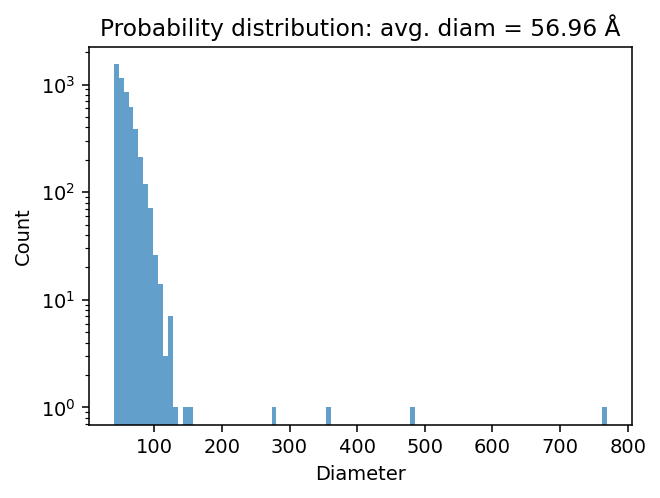

In [15]:
lo_shape, lo_diam, lo_std = [-1, 35.00171706526209, 37.88649765362167]
hi_shape, hi_diam, hi_std = [-1, 531.4308346353963, 348.38150246164275]
lo_weight = 0.9997304126284063

def area_weighted_skewnorm_pdf(d, weight2, shape2, loc2, scale2, shape3, loc3, scale3):
    pdf2 = skewnorm.pdf(d, a=shape2, loc=loc2, scale=scale2)
    pdf3 = skewnorm.pdf(d, a=shape3, loc=loc3, scale=scale3)
    area = d**2
    return (weight2 * pdf2 * area) + ((1 - weight2) * pdf3 * area)

def sample_area_weighted_skewnorm(n_samples, weight2,
                                   shape2, loc2, scale2,
                                   shape3, loc3, scale3,
                                   d_min, d_max, oversample_factor=5):
    # Create a grid over which to evaluate the PDF
    d_grid = np.linspace(d_min, d_max, 1000)
    pdf_vals = area_weighted_skewnorm_pdf(d_grid, weight2, shape2, loc2, scale2,
                                                   shape3, loc3, scale3)
    pdf_max = pdf_vals.max()

    samples = []
    while len(samples) < n_samples:
        # Propose uniformly
        d_proposed = np.random.uniform(d_min, d_max, oversample_factor * n_samples)
        # Evaluate the custom PDF at these points
        p = area_weighted_skewnorm_pdf(d_proposed, weight2, shape2, loc2, scale2,
                                                     shape3, loc3, scale3)
        accept_prob = p / pdf_max
        u = np.random.rand(len(d_proposed))
        accepted = d_proposed[u < accept_prob]
        samples.extend(accepted)

    return np.array(samples[:n_samples])

def weighted_skewnorm_pdf(d, weight2, shape2, loc2, scale2, shape3, loc3, scale3):
    pdf2 = skewnorm.pdf(d, a=shape2, loc=loc2, scale=scale2)
    pdf3 = skewnorm.pdf(d, a=shape3, loc=loc3, scale=scale3)
    return (weight2 * pdf2) + ((1 - weight2) * pdf3)

def sample_weighted_skewnorm(n_samples, weight2,
                             shape2, loc2, scale2,
                             shape3, loc3, scale3,
                             d_min, d_max, oversample_factor=5):
    # Create a grid over which to evaluate the PDF
    d_grid = np.linspace(d_min, d_max, 1000)
    pdf_vals = weighted_skewnorm_pdf(d_grid, weight2, shape2, loc2, scale2,
                                                   shape3, loc3, scale3)
    pdf_max = pdf_vals.max()

    samples = []
    while len(samples) < n_samples:
        # Propose uniformly
        d_proposed = np.random.uniform(d_min, d_max, oversample_factor * n_samples)
        # Evaluate the custom PDF at these points
        p = weighted_skewnorm_pdf(d_proposed, weight2, shape2, loc2, scale2,
                                                     shape3, loc3, scale3)
        accept_prob = p / pdf_max
        u = np.random.rand(len(d_proposed))
        accepted = d_proposed[u < accept_prob]
        samples.extend(accepted)

    return np.array(samples[:n_samples])


# avg_diam = 90
# fibril_volume = np.pi*(avg_diam/2)**2 * np.array(args['multi_length']).mean()
# grid_volume = (args['vd']*args['voxel_size']) * (args['ld']*args['voxel_size'])**2

# num_fibrils = int((args['fibril_Vfrac'] * grid_volume) / fibril_volume)

# diams = sample_area_weighted_skewnorm(
diams = sample_weighted_skewnorm(
    # n_samples=int(1e4),
    n_samples=5000,
    # n_samples=args['fibril_amount'],
    weight2=lo_weight,
    shape2=lo_shape, loc2=lo_diam, scale2=lo_std,
    shape3=hi_shape, loc3=hi_diam, scale3=hi_std,
    d_min=args['diam_limits'][0], d_max=args['diam_limits'][1]
    # d_min=args['diam_limits'][0], d_max=1200
)

# avg_diam = diams.mean()

# import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5,3.5), dpi=140)
ax.hist(diams, bins=100, density=False, alpha=0.7)
ax.set_xlabel("Diameter")
ax.set_ylabel("Count")
ax.set_title(f"Probability distribution: avg. diam = {diams.mean():.2f} Å")
ax.set_yscale('log')
plt.show()

In [26]:
# # Check fibrils library path
# fibrilsPath = notebookPath.joinpath('fibrils_library_v1')

# fibril_paths = [f for f in sorted(fibrilsPath.glob('fibril*'))]
# fibril_diams = np.array([float(f.name.split('_')[1].split('-')[-1]) for f in fibril_paths])
# fibril_lengths = np.array([float(f.name.split('_')[-1].split('-')[-1]) for f in fibril_paths])

# fibril_diam = 627
# fibril_length = 400

# idx = np.argmin(np.abs(fibril_diams - fibril_diam) + np.abs(fibril_lengths - fibril_length))

# fibril_paths[idx].name

### Build voxelgrid coordinates

In [77]:
sweepPath

PosixPath('/projects/anle1278/nrss_simple_fibril_sweeps/multiple_fibril_sweeps_outputs/paramsID-35_fibril_amount_afm_lat_scale')

In [24]:
sweep_vals = args['sweep_params_values']
list(product(*sweep_vals))

[(0.1, [600, 600]),
 (0.1, [600, 1200]),
 (0.1, [1200, 1200]),
 (0.2, [600, 600]),
 (0.2, [600, 1200]),
 (0.2, [1200, 1200]),
 (0.3, [600, 600]),
 (0.3, [600, 1200]),
 (0.3, [1200, 1200])]

Sweeping params:   0%|          | 0/9 [00:00<?, ?it/s]

(0.1, [600, 600]): 1045 fibrils


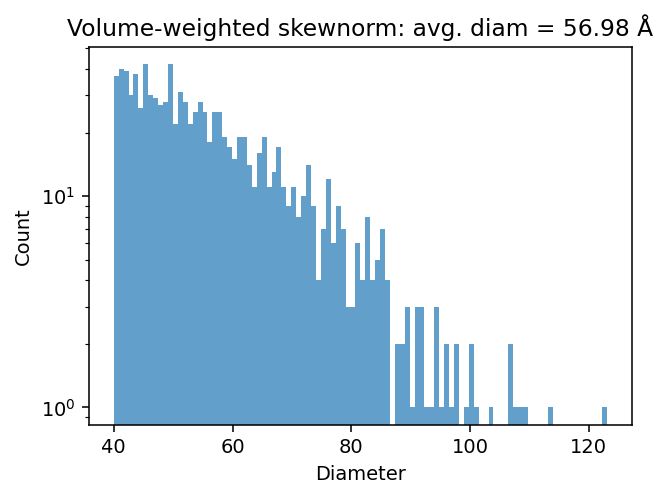

Sweeping params:  11%|█         | 1/9 [01:08<09:04, 68.10s/it]

(0.1, [600, 1200]): 696 fibrils


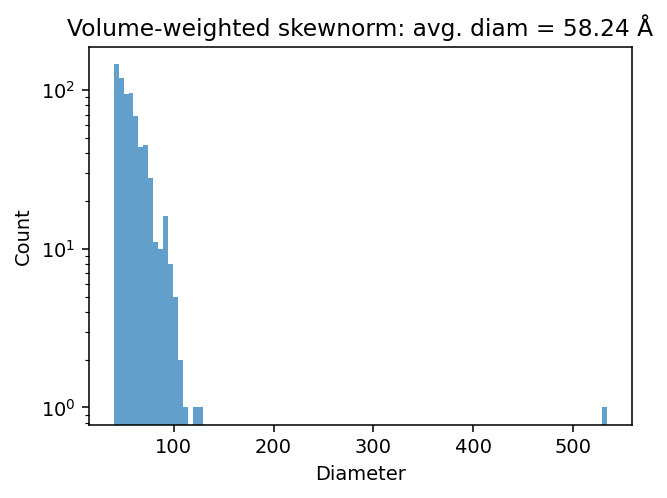

Sweeping params:  22%|██▏       | 2/9 [02:05<07:13, 61.88s/it]

(0.1, [1200, 1200]): 522 fibrils


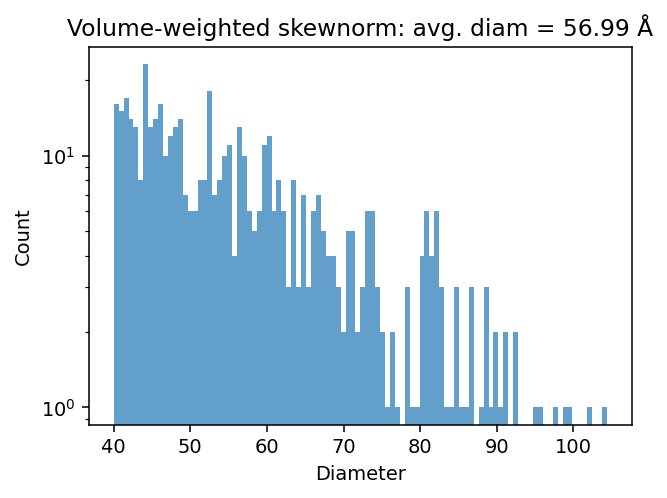

Sweeping params:  33%|███▎      | 3/9 [03:10<06:20, 63.47s/it]

(0.2, [600, 600]): 2090 fibrils


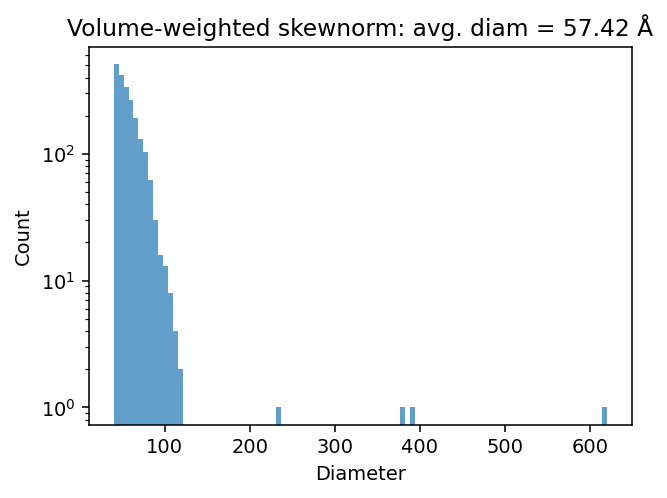

Sweeping params:  44%|████▍     | 4/9 [05:38<08:03, 96.69s/it]

(0.2, [600, 1200]): 1393 fibrils


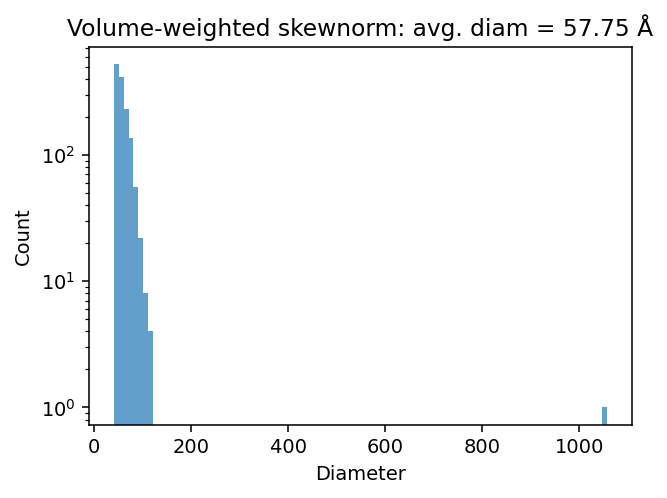

Sweeping params:  56%|█████▌    | 5/9 [07:50<07:17, 109.42s/it]

(0.2, [1200, 1200]): 1045 fibrils


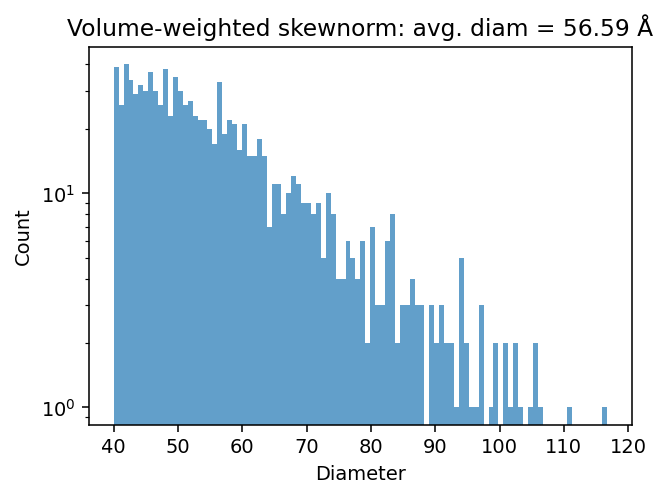

Sweeping params:  67%|██████▋   | 6/9 [10:00<05:49, 116.51s/it]

(0.3, [600, 600]): 3135 fibrils


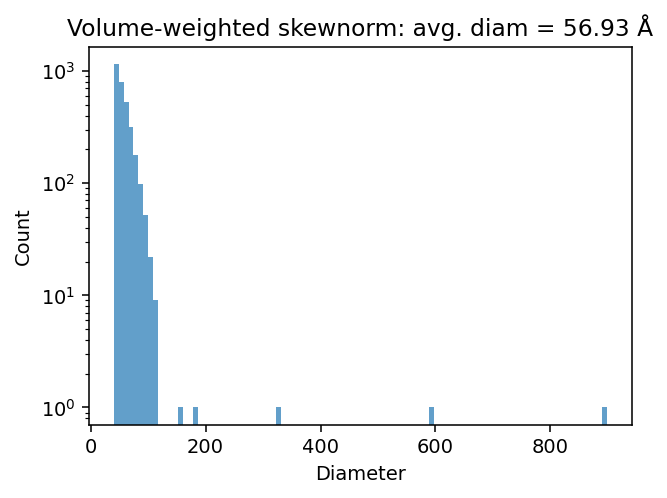

Sweeping params:  78%|███████▊  | 7/9 [13:47<05:05, 152.58s/it]

(0.3, [600, 1200]): 2090 fibrils


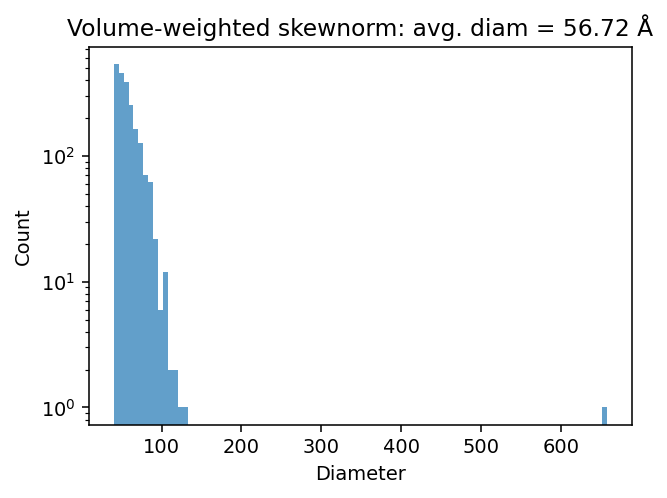

Sweeping params:  89%|████████▉ | 8/9 [16:17<02:31, 151.83s/it]

(0.3, [1200, 1200]): 1567 fibrils


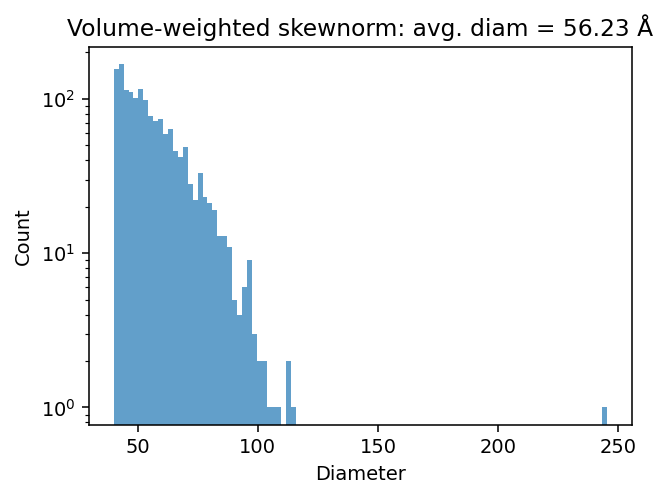

Sweeping params: 100%|██████████| 9/9 [19:31<00:00, 130.21s/it]


In [25]:
# One for distributions now!

# Make list of all tuples for parameter and value to be swept over
sweep_keys = args['sweep_params']
sweep_vals = args['sweep_params_values']
combinations = list(product(*sweep_vals))

# Create folder for these argument parameters
params_ID = args['params_ID']
folder_string = f'paramsID-{params_ID}'
for sweep_key in sweep_keys:
    folder_string = folder_string + '_' + sweep_key
sweepPath = savePath.joinpath(folder_string)
sweepPath.mkdir(exist_ok=True)

# Save arguments dictionary in the above folder
json_ready_args = {
    k: v.tolist() if isinstance(v, np.ndarray) else v
    for k, v in args.items()
}
with sweepPath.joinpath('args.json').open('w') as f:
    json.dump(json_ready_args, f)

# display(args)
for combo in tqdm(combinations[::1], 'Sweeping params'):  
    sweep_args = args.copy()
    for k, v in zip(sweep_keys, combo):
        sweep_args[k] = v

    if isinstance(sweep_args['fibril_amount'], float):
        avg_diam = 57  # Check this approx value in earlier cell
        fibril_volume = np.pi*(avg_diam/2)**2 * np.array(sweep_args['multi_length']).mean()
        grid_volume = (sweep_args['vd']*sweep_args['voxel_size']) * (sweep_args['ld']*sweep_args['voxel_size'])**2
        num_fibrils = int((sweep_args['fibril_amount'] * grid_volume) / fibril_volume)
    elif isinstance(sweep_args['fibril_amount'], int):
        num_fibrils = sweep_args['fibril_amount']
    else:
        raise Error

    print(f'{combo}: {num_fibrils} fibrils')
    
    # diams = sample_area_weighted_skewnorm(
    diams = sample_weighted_skewnorm(
        n_samples=num_fibrils,
        weight2=lo_weight,
        shape2=lo_shape, loc2=lo_diam, scale2=lo_std,
        shape3=hi_shape, loc3=hi_diam, scale3=hi_std,
        d_min=sweep_args['diam_limits'][0], d_max=sweep_args['diam_limits'][1]
    )
    
    fig, ax = plt.subplots(figsize=(5,3.5), dpi=140)
    ax.hist(diams, bins=100, density=False, alpha=0.7)
    ax.set_xlabel("Diameter")
    ax.set_ylabel("Count")
    ax.set_title(f"Volume-weighted skewnorm: avg. diam = {diams.mean():.2f} Å")
    ax.set_yscale('log')
    plt.show()
    plt.close('all')

    fibril_points = []
    fibril_colors = []
    for i, diam in enumerate(diams):
        multi_idx = (diam > np.array(args['diam_boundaries'])).nonzero()[0][-1]
        # print(multi_idx)
                
        length = sweep_args['multi_length']
        length = np.random.normal(loc=sweep_args['multi_length'][multi_idx], scale=sweep_args['multi_length_std'][multi_idx])

        # Make fibril
        fibril_coords = voxelized_cylinder(diam, length, sweep_args['voxel_size']*0.7)
        
        # Set molecular orientations
        fibril_vectors = mol_orient_vectors_cylinder(sweep_args['multi_core_orientation'][multi_idx], 
                                                     fibril_coords, 
                                                     orient_std = sweep_args['multi_core_orientation_std'][multi_idx])


        # Update certain args by selecting value from prob. dist. fxn           
        fibril_tilt = np.random.normal(loc=sweep_args['multi_tilt'][multi_idx], scale=sweep_args['multi_tilt_std'][multi_idx])
        
        # Rotate fibril tilt theta about 'y'; choose a random inplane psi about 'z'
        rotation = R.from_euler('zyz', [np.random.normal(loc=sweep_args['multi_roll'][multi_idx], scale=sweep_args['multi_roll_std'][multi_idx]), 
                                        fibril_tilt, 
                                        np.random.uniform(low=0,high=360)], degrees=True)
        rotated_fibril = rotation.apply(fibril_coords)
        rotated_fibril_vectors = rotation.apply(fibril_vectors)
    
        fibril_RGB_values = (rotated_fibril_vectors+1)/2
        
        # Translate rotated fibril to a random XYZ coordinate
        # Establish limits based on fibril length, width, height:
        rand_x = np.random.uniform(low=-rotated_fibril[:,0].min(), 
                                   high=(sweep_args['ld'] * sweep_args['voxel_size']) 
                                         - rotated_fibril[:,0].max())
        rand_y = np.random.uniform(low=-rotated_fibril[:,1].min(), 
                                   high=(sweep_args['ld'] * sweep_args['voxel_size']) 
                                         - rotated_fibril[:,1].max())
        rand_z = np.random.uniform(low=-rotated_fibril[:,2].min(), 
                                   high=(sweep_args['vd'] * sweep_args['voxel_size']) 
                                         - rotated_fibril[:,2].max())
        
        moved_fibril = rotated_fibril + [rand_x,rand_y,rand_z]

        fibril_points.append(moved_fibril)
        fibril_colors.append(fibril_RGB_values)

    core_pcd = o3d.geometry.PointCloud()
    core_pcd.points.extend(np.vstack(fibril_points))
    core_pcd.colors.extend(np.vstack(fibril_colors))
    
    # Voxelize PointCloud
    core_vg = o3d.geometry.VoxelGrid.create_from_point_cloud(core_pcd, voxel_size=sweep_args["voxel_size"])

    # Save VoxelGrid 
    label = "_".join([f"{k}-{v}" for k, v in zip(sweep_keys, combo)])
    o3d.io.write_voxel_grid(str(sweepPath.joinpath(f'{label}_cores.ply')), core_vg)

    gc.collect()

In [ ]:
vgridPath = sorted(sweepPath.glob('*0.03.ply'))[1]
loaded_voxel_grid = o3d.io.read_voxel_grid(str(vgridPath))
loaded_voxel_grid

In [ ]:
# import numpy as np
# import open3d as o3d
# from open3d.visualization.rendering import OffscreenRenderer, MaterialRecord, Camera
# from open3d.visualization import rendering

# def render_voxel_grid(voxel_grid, output_png, azim=45, elev=30, zoom=1.0, width=1024, height=768):
#      # Create renderer
#     renderer = OffscreenRenderer(width, height)
#     scene = renderer.scene
#     scene.set_background([1, 1, 1, 1])  # white background

#     # Add voxel grid with default material
#     mat = rendering.MaterialRecord()
#     mat.shader = "defaultUnlit"
#     scene.add_geometry("voxels", voxel_grid, mat)

#     # Compute center of scene
#     bounds = voxel_grid.get_axis_aligned_bounding_box()
#     center = bounds.get_center()
#     extent = bounds.get_extent().max()

#     # Convert azimuth and elevation to camera position
#     azim_rad = np.deg2rad(azim)
#     elev_rad = np.deg2rad(elev)
#     cam_distance = extent * zoom
#     cam_pos = np.array([
#         cam_distance * np.cos(elev_rad) * np.cos(azim_rad),
#         cam_distance * np.cos(elev_rad) * np.sin(azim_rad),
#         cam_distance * np.sin(elev_rad)
#     ]) + center

#     # Setup camera lookat
#     scene.camera.look_at(center, cam_pos, np.array([0, 0, 1]))

#     # Render and save
#     img = renderer.render_to_image()
#     o3d.io.write_image(output_png, img)

# # Example usage
# # voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(...)
# render_voxel_grid(loaded_voxel_grid, "output.png", azim=60, elev=20, zoom=1.5)


In [ ]:
# pcd = o3d.geometry.PointCloud()
# pcd.points.extend(np.array([[0,0,0], [100,100,100]]))
# pcd.colors.extend(np.array([[1,1,1], [1,1,1]]))

# for elev in tqdm([-60,-45,0,45,60]):
#     for azim in [0,45,90,135,180,225,270,315]:
#         print(elev,azim)
#         plot_pointcloud_with_legend(pcd, background='white', show=True, zoom=1, 
#                                     axes_origin=(0, 0, 0), 
#                                     sphere_origin=(40,40,50), 
#                                     axes_length=35, 
#                                     savePath=sphere_legends_path.joinpath(f'elev{elev}_azim{azim}.png'),
#                                     elev=elev, azim=azim, hide_axes=True)

In [ ]:
plot

## Arrange fibrils

In [ ]:
rotated_fibril.shape

In [ ]:
points = np.array([[1,1,1],
                   [2,2,2]])
colors = np.array([[1,1,1,1],
                   [2,2,2,2]])

In [ ]:
pcd = o3d.geometry.PointCloud()
pcd.points.extend(points)
pcd.colors.extend(colors)

In [ ]:
pcd.normals

In [ ]:
np.asarray(pcd.colors)

In [ ]:
pcd

In [ ]:
o3d.visualization.EV.set(pc)

## Use open3D to voxelize point cloud

In [ ]:
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pc, voxel_size=10)
voxel_grid

In [ ]:
# Convert voxel grid to list of voxels, with grid index & color

voxels = vg.get_voxels()  # returns list of voxels
indices = np.stack(list(vx.grid_index for vx in voxels))
colors = np.stack(list(vx.color for vx in voxels))

voxels

In [ ]:
indices.max()

In [ ]:
# visualize, will need to restart kernel after :O
o3d.visualization.draw_geometries([vg])

## Save open3d voxelgrids